# ECE 57000 Assignment 3 Exercise

Your Name: Andy Tan

# Important submission information

1. Follow the instructions in [uploader.ipynb](https://colab.research.google.com/drive/1c0RcQQl7I_rty42BwkFvCIBexBtCNAI1) to convert your ipynb file into PDF format.
2. Please make sure to select the corresponding pages for each exercise when you submitting your PDF to Gradescope. Make sure to include both the **output** and the **code** when selecting pages. (You do not need to include the instruction for the exercises)

**We may assess a 20% penalty for those who do not correctly follow these steps.**

Prepare the packages we will use.

In [ ]:
import time
from typing import List, Dict

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

import numpy as np

## Exercise 0: Train your model on GPU (0 points)

Some tasks in this assignment can take a long time if you run it on the CPU. For example, based on our solution of Exercise 3 Task 4 (Transfer Learning: finetuning of a pretrained model (resnet18)), it will take roughly 2 hours to train the model end-to-end (the complete model and not only the last fc layer) for 1 epoch on CPU. Hence, we highly recommend you try to train your model on a GPU.

To do so, first you need to enable the GPU on Colab (this will restart the runtime). Click `Runtime`-> `Change runtime type` and select the `Hardware accelerator` there.  You can then run the following code to see if the GPU is correctly initialized and available.

**Note**: If you would like to avoid GPU overages on Colab, we would suggest writing and debugging your code before switching on the GPU runtime. Otherwise, the time you spent debugging code will likely count against your GPU usage. Once you have the code running, you can switch on the GPU runtime and train the model much faster.

In [ ]:
print(f'Can I can use GPU now? -- {torch.cuda.is_available()}')

Can I can use GPU now? -- True


### You must manually move your model and data to the GPU (and sometimes back to the cpu)
After setting the GPU up on colab, then you should put your **model** and **data** to GPU. We give a simple example below. You can use `to` function for this task. See [torch.Tensor.to](https://pytorch.org/docs/stable/generated/torch.Tensor.to.html) to move a tensor to the GPU (probably your mini-batch of data in each iteration) or [torch.nn.Module.to](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.to) to move your NN model to GPU (assuming you create subclass [torch.nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html)). Note that `to()` of tensor returns a NEW tensor while `to` of a NN model will apply this in-place. To be safe, the best semantics are `obj = obj.to(device)`. For printing, you will need to move a tensor back to the CPU via the `cpu()` function.

Once the model and input data are on the GPU, everything else can be done the same.  This is the beauty of PyTorch GPU acceleration.  None of the other code needs to be altered.

To summarize, you need to 1) enable GPU acceleration in Colab, 2) put the model on the GPU, and 3) put the input data (i.e., the batch of samples) onto the GPU using `to()` after it is loaded by the data loaders (usually you only put one batch of data on the GPU at a time).

In [ ]:
rand_tensor = torch.rand(5,2)
simple_model = nn.Sequential(nn.Linear(2,10), nn.ReLU(), nn.Linear(10,1))
print(f'input is on {rand_tensor.device}')
print(f'model parameters are on {[param.device for param in simple_model.parameters()]}')
print(f'output is on {simple_model(rand_tensor).device}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# ----------- <Your code> ---------------
# Move rand_tensor and model onto the GPU device
rand_tensor = rand_tensor.to(device)
simple_model = simple_model.to(device)
# --------- <End your code> -------------
print(f'input is on {rand_tensor.device}')
print(f'model parameters are on {[param.device for param in simple_model.parameters()]}')
print(f'output is on {simple_model(rand_tensor).device}')

input is on cpu
model parameters are on [device(type='cpu'), device(type='cpu'), device(type='cpu'), device(type='cpu')]
output is on cpu
input is on cuda:0
model parameters are on [device(type='cuda', index=0), device(type='cuda', index=0), device(type='cuda', index=0), device(type='cuda', index=0)]
output is on cuda:0


## Exercise 1: Implement a convolutional layer from scratch (10 points)

In this exercise, you will implement a basic 2D convolution function using **NumPy**. The convolution will use the following specifications:

* Zero padding (pad the input so that the output has the same height and width as the input),
* A 3×3 kernel,
* Stride = 1.

The function should handle inputs with multiple channels. In particular, it takes:

* An input array of shape `[H, W, C_in]`, where `H=4` and `W=4` are the height and width of the image, and `C_in=1` is the number of input channels in our example.
* A kernel of shape `[C_out, H, W, C_in]`, which produces an output with `C_out=2` channels in our example.


In [ ]:
def conv2d_numpy(input_tensor: np.ndarray,
               kernel: np.ndarray) -> np.ndarray:

    h, w, in_channels = input_tensor.shape
    out_channels = kernel.shape[0]

    # Hint: check np.pad() or pad the input by yourself; use three nested for loops to loop over height, width, out_channels
    # Hint: identify how many pixels should be padded, identify the input patch and kernel for given locations (loop over h, w) and out channel (loop over out_channels)
    # ----------- <Your code> ---------------

    # Pad refer https://numpy.org/doc/stable/reference/generated/numpy.pad.html
    padded = np.pad( input_tensor, ((1,1),(1,1),(0,0)), 'constant')
    # Output Matrix
    output = np.zeros((h, w, out_channels))
    for channel in range(out_channels):
      for height in range(h):
        for width in range(w):

# Refer https://medium.com/@whyamit404/numpy-2d-convolution-a-practical-guide-b01a759712e2
          patch = padded [height:height+3, width:width+3] # +3 due to kernel size
          output[height, width, channel] = np.sum(patch * kernel[channel])

    # --------- <End your code> -------------

    return output

input_tensor = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16]
]).reshape(4, 4, 1)

# Kernel: 2 output channels, 3x3 size, 1 input channel
kernel = np.zeros((2, 3, 3, 1))
# First kernel: all ones (blur/average)
kernel[0] = np.ones((3, 3, 1))
# Second kernel: horizontal edge detection [1,0,-1] pattern
kernel[1] = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
]).reshape(3, 3, 1)

# Expected output shape: (4, 4, 2)
expected_output = np.array([
    [[14, -8], [24, -4], [30, -4], [22, 10]],
    [[33, -18], [54, -6], [63, -6], [45, 21]],
    [[57, -30], [90, -6], [99, -6], [69, 33]],
    [[46, -24], [72, -4], [78, -4], [54, 26]]
])

output = conv2d_numpy(input_tensor, kernel)
assert (output == expected_output).all()

## Exercise 2: Why use a CNN rather than only fully connected layers? (30 points)

In this exercise, you will build two models for the **MNIST** dataset: one uses only fully connected layers and another uses a standard CNN layout (convolution layers everywhere except the last layer is fully connected layer). Note, you will need to use cross entropy loss as your objective function. The two models should be built with roughly the same accuracy performance, your task is to compare the number of network parameters (a huge number of parameters can affect training/testing time, memory requirements, overfitting, etc.).

### Task 1: Prepare train and test function

We will create our train and test procedure in these two functions. The train function should apply one epoch of training. The functions inputs should take everything we need for training and testing and return some logs.

#### Arguments requirement:
* For the `train` function, it takes the `model`, `loss_fn`, `optimizer`, `train_loader`, and `epoch` as arguments.
    * `model`: the classifier, or deep neural network, should be an instance of `nn.Module`.
    * `loss_fn`: the loss function instance. For example, `nn.CrossEntropy()`, or `nn.L1Loss()`, etc.
    * `optimizer`: should be an instance of `torch.optim.Optimizer`. For example, it could be `optim.SGD()` or `optim.Adam()`, etc.
    * `train_loader`: should be an instance of `torch.utils.data.DataLoader`.
    * `epoch`: the current number of epoch. Only used for log printing.(default: 1.)

* For the `test` function, it takes all the inputs above except for the optimizer (and it takes a test loader instead of a train loader).

#### Log requirement:
Here are some further requirements:
* In the `train` function, print the log 8-10 times per epoch. The print statement should be:
```python
print(f'Epoch {epoch}: [{batch_idx*len(images)}/{len(train_loader.dataset)}] Loss: {loss.item():.3f}')
```
* In the `test` function, print the log after the testing. The print statement is:
```python
print(f"Test result on epoch {epoch}: total sample: {total_num}, Avg loss: {test_stat['loss']:.3f}, Acc: {100*test_stat['accuracy']:.3f}%")
```

#### Return requirement
* The `train` function should return a list, which the element is the loss per batch, i.e., one loss value for every batch.
* The `test` function should return a dictionary with three keys: "loss", "accuracy", and "prediction". The values are the average loss of all the testset, average accuracy of all the test dataset, and the prediction of all test dataset.

#### Other requirement:
* In the `train` function, the model should be updated in-place, i.e., do not copy the model inside `train` function.

In [ ]:
def train(model: nn.Module,
          loss_fn: nn.modules.loss._Loss,
          optimizer: torch.optim.Optimizer,
          train_loader: torch.utils.data.DataLoader,
          epoch: int=1)-> List:
    # ----------- <Your code> ---------------
    # Reference for Module https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html
    model.train()
    # Use example to enable GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    # Reference for Dataloader https://docs.pytorch.org/docs/stable/data.html

    # Get batches per epoch to print 8 times per epoch
# https://stackoverflow.com/questions/63930621/how-to-get-the-total-number-of-batch-iteration-from-pytorch-dataloader
    printInterval = len(train_loader) // 8

    # Edge case where fewer than 1 batch size
    if printInterval < 1:
      printInterval = 1

    # Loss List
    train_loss = []

# Refer https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
    for batch_idx, batch in enumerate(train_loader):
      images = batch[0]
      images = images.to(device)

      labels = batch[1]
      labels = labels.to(device)

      # zero gradient to not accumulate
      optimizer.zero_grad()

      # Forward
      outputs = model(images)
      loss = loss_fn(outputs, labels)

      # Backward
      loss.backward()
      optimizer.step()

      train_loss.append(loss.item())

      if batch_idx % printInterval == 0:
        print(f'Epoch {epoch}: [{batch_idx*len(images)}/{len(train_loader.dataset)}] Loss: {loss.item():.3f}')

    # ----------- <End Your code> ---------------
    assert len(train_loss) == len(train_loader)
    return train_loss

def test(model: nn.Module,
         loss_fn: nn.modules.loss._Loss,
         test_loader: torch.utils.data.DataLoader,
         epoch: int=1)-> Dict:
    # ----------- <Your code> ---------------
    # Refer https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    correct = 0
    lossTotal = 0
    total_num = 0
    predictionTotal = []

    # Refer https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
    with torch.no_grad(): # No gradient calculations since testing
      for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # len to return batch size
        sampleNum = len(images)
        output = model(images)

        # Accumulate loss but factor in that the last batch may have a different sample size
        lossTotal += loss_fn(output, labels).item() * sampleNum
        # Torch max returns score and highest prediction. Do not need score
        _, prediction = torch.max(output,1)

        # .item() for memory
        total_num += sampleNum
        correct += (prediction == labels).sum().item()
        # From online, adding the .cpu moves it to cpu to not bottleneck GPU
        predictionTotal.append(prediction.cpu())

    avgLoss = lossTotal / total_num
    accuracy = correct / total_num
    predictions = torch.cat(predictionTotal, dim=0) # Flatten

    test_stat = {"loss": avgLoss, "accuracy": accuracy, "prediction":predictions}
    print(f"Test result on epoch {epoch}: total sample: {total_num}, Avg loss: {test_stat['loss']:.3f}, Acc: {100*test_stat['accuracy']:.3f}%")

    # ----------- <End Your code> ---------------
    # dictionary should include loss, accuracy and prediction
    assert "loss" and "accuracy" and "prediction" in test_stat.keys()
    # "prediction" value should be a 1D tensor
    assert len(test_stat["prediction"]) == len(test_loader.dataset)
    assert isinstance(test_stat["prediction"], torch.Tensor)
    return test_stat


### Task 2: Following the structure used in the reference, you should create

*   One network named `OurFC` which should consist with only fully connected layers
    * You should decide how many layers and how many hidden dimensions you want in your network
    * Your final accuracy on the test dataset should lie roughly around 97% ($\pm$2%)
    * There is no need to make the neural network unnecessarily complex, your total training time should no longer than 3 mins
*   Another network named `OurCNN` which applys a standard CNN structure
    * Again, you should decide how many layers and how many channels you want for each layer.
    * Your final accuracy on the test dataset should lie roughly around 97% ($\pm$2%)
    * A standard CNN structure can be composed as **[Conv2d, MaxPooling, ReLU] x num_conv_layers + FC x num_fc_layers**
* Train and test your network on MNIST data as in the reference.
* Notice You can always use the `train` and `test` function you write throughout this assignment.
* The code below will also print out the number of parameters for both neural networks to allow comparison.
* (You can use multiple cells if helpful but make sure to run all of them to receive credit.)


In [ ]:
# Download MNIST and transformation
# ----------- <Your code> ---------------
# Referenced week-5-demo-mlp-on-mnist
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.1307,), (0.3081,))])

# Batch size sets
batchTrainSize = 60
batchTestSize = 60

# Train Set
trainSet = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
trainLoad = torch.utils.data.DataLoader(dataset=trainSet, batch_size = batchTrainSize, shuffle = True)
# Test Set
testSet = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)
testLoad = torch.utils.data.DataLoader(dataset=testSet, batch_size = batchTestSize, shuffle = False)

# ----------- <End Your code> ---------------


In [ ]:
# Build OurFC class and OurCNN class.
# ----------- <Your code> ---------------
# Referenced week-5-demo-mlp-on-mnist
class OurFC(nn.Module):
  def __init__(self):
    super(OurFC, self).__init__() # Inherit nn.Module
    self.flatten = nn.Flatten() # Flatten to 784 pixels
    self.L1 = nn.Linear(28*28, 200) # Format is input size, hidden size
    self.L2 = nn.Linear(200, 300) # Choose hidden layers of 300
    self.L3 = nn.Linear(300, 200) # Choose hidden layers of 300
    self.L4 = nn.Linear(200, 10) # Output size is 10 (10 numbers)
  def forward(self, x):
    x = self.flatten(x)

    # Layer 1
    x = self.L1(x)
    x = F.relu(x) # F.relu used similar to nn.relu but function

    # Layer 2
    x = self.L2(x)
    x = F.relu(x)

    # Layer 3
    x = self.L3(x)
    x = F.relu(x)

    # Output Layer
    x = self.L4(x)
    return x

class OurCNN(nn.Module):
  def __init__(self):
    super(OurCNN, self).__init__()
    # Initiate Conv layers
    self.conv1 = nn.Conv2d(1,16, kernel_size=3, padding = 1)
    self.conv2 = nn.Conv2d(16,32, kernel_size=3, padding = 1)
    # Hidden layer choice is 1568 (32*7*7)
    self.L1 = nn.Linear(32 * 7 * 7, 32)
    self.L2 = nn.Linear(32, 10)

  def forward(self, x):
    # Input = 1x28x28 Image, 16 filters, output = 16 x 28 x 28
    x = self.conv1(x)
    x = F.relu(x)
    # Max Pool Kernel 2x2 therefore output is 16x14x14
    x = F.max_pool2d(x, 2)

    # Input = 16x14x14 32 filters Output = 32x14x14
    x = self.conv2(x)
    x = F.relu(x)
    # Max Pool Kernel is 2x2, Output is = 32x7x7
    x = F.max_pool2d(x, 2)

    # Flatten to use fully connected layer Input = 1568
    # Could Hard code as x.view(-1, 1568)
    x = x.view(x.size(0), -1)

    # Hidden Layer choice = 32
    x = self.L1(x)
    x = F.relu(x)

    # Hidden Layer choice = 32 to 10
    x = self.L2(x)

    return x
# ----------- <End Your code> ---------------


In [ ]:
# Let's first train the FC model. Below are their common (shared) hyperparameters.
criterion = nn.CrossEntropyLoss()

start = time.time()
max_epoch = 3
# ----------- <Your code> ---------------
# Train OurFC

# Send to GPU
ourFC = OurFC().to(device)

# Stochastic Gradient Optimizer
optimizerFC = optim.SGD(ourFC.parameters(), lr=0.01, momentum = 0.9)

# Train and test each epoch to see changes in loss
for epoch in range(1, max_epoch+1):
  train(ourFC,criterion, optimizerFC, trainLoad, epoch)
  test(ourFC, criterion, testLoad, epoch)

# ----------- <End Your code> ---------------
end = time.time()
print(f'Finished Training after {end-start} s ')

Epoch 1: [0/60000] Loss: 2.295
Epoch 1: [7500/60000] Loss: 0.736
Epoch 1: [15000/60000] Loss: 0.447
Epoch 1: [22500/60000] Loss: 0.411
Epoch 1: [30000/60000] Loss: 0.215
Epoch 1: [37500/60000] Loss: 0.425
Epoch 1: [45000/60000] Loss: 0.329
Epoch 1: [52500/60000] Loss: 0.089
Test result on epoch 1: total sample: 10000, Avg loss: 0.205, Acc: 94.560%
Epoch 2: [0/60000] Loss: 0.227
Epoch 2: [7500/60000] Loss: 0.100
Epoch 2: [15000/60000] Loss: 0.355
Epoch 2: [22500/60000] Loss: 0.103
Epoch 2: [30000/60000] Loss: 0.194
Epoch 2: [37500/60000] Loss: 0.100
Epoch 2: [45000/60000] Loss: 0.134
Epoch 2: [52500/60000] Loss: 0.093
Test result on epoch 2: total sample: 10000, Avg loss: 0.210, Acc: 94.410%
Epoch 3: [0/60000] Loss: 0.140
Epoch 3: [7500/60000] Loss: 0.082
Epoch 3: [15000/60000] Loss: 0.087
Epoch 3: [22500/60000] Loss: 0.120
Epoch 3: [30000/60000] Loss: 0.359
Epoch 3: [37500/60000] Loss: 0.314
Epoch 3: [45000/60000] Loss: 0.073
Epoch 3: [52500/60000] Loss: 0.107
Test result on epoch 3: t

In [ ]:
# Let's then train the OurCNN model.
start = time.time()
# ----------- <Your code> ---------------

# Send to GPU
ourCNN = OurCNN().to(device)

# SGD Optimization chosen
optimizerCNN = optim.SGD(ourCNN.parameters(), lr=0.01, momentum = 0.9)

# For print out later for start time

for epoch in range(1, max_epoch+1):
  train(ourCNN,criterion, optimizerCNN, trainLoad, epoch)
  test(ourCNN, criterion, testLoad, epoch)

# ----------- <End Your code> ---------------
end = time.time()
print(f'Finished Training after {end-start} s ')

Epoch 1: [0/60000] Loss: 2.312
Epoch 1: [7500/60000] Loss: 0.161
Epoch 1: [15000/60000] Loss: 0.105
Epoch 1: [22500/60000] Loss: 0.166
Epoch 1: [30000/60000] Loss: 0.031
Epoch 1: [37500/60000] Loss: 0.055
Epoch 1: [45000/60000] Loss: 0.244
Epoch 1: [52500/60000] Loss: 0.125
Test result on epoch 1: total sample: 10000, Avg loss: 0.061, Acc: 97.890%
Epoch 2: [0/60000] Loss: 0.011
Epoch 2: [7500/60000] Loss: 0.113
Epoch 2: [15000/60000] Loss: 0.078
Epoch 2: [22500/60000] Loss: 0.094
Epoch 2: [30000/60000] Loss: 0.012
Epoch 2: [37500/60000] Loss: 0.020
Epoch 2: [45000/60000] Loss: 0.014
Epoch 2: [52500/60000] Loss: 0.143
Test result on epoch 2: total sample: 10000, Avg loss: 0.046, Acc: 98.490%
Epoch 3: [0/60000] Loss: 0.030
Epoch 3: [7500/60000] Loss: 0.005
Epoch 3: [15000/60000] Loss: 0.059
Epoch 3: [22500/60000] Loss: 0.055
Epoch 3: [30000/60000] Loss: 0.084
Epoch 3: [37500/60000] Loss: 0.010
Epoch 3: [45000/60000] Loss: 0.012
Epoch 3: [52500/60000] Loss: 0.010
Test result on epoch 3: t

In [ ]:
ourfc = OurFC()
total_params = sum(p.numel() for p in ourfc.parameters())
print(f'OurFC has a total of {total_params} parameters')

ourcnn = OurCNN()
total_params = sum(p.numel() for p in ourcnn.parameters())
print(f'OurCNN has a total of {total_params} parameters')

OurFC has a total of 279510 parameters
OurCNN has a total of 55338 parameters


Questions (0 points, just for understanding): Which one has more parameters?  Which one is likely to have less computational cost when deployed? Which one took longer to train?

The FC Model has more parameters while producing slightly worse results. Due to sharing weights.

The FC Model is simplier and does not do convolution

The CNN model took longer to train.

## Exercise 3: Train classifier on CIFAR-10 data. (30 points)
Now, lets move our dataset to color images. CIFAR-10 dataset is another widely used dataset. Here all images have colors, i.e each image has 3 color channels instead of only one channel in MNIST. You need to pay more attention to the dimension of the data as it passes through the layers of your network.

### Task 1: Create data loaders
* Load CIFAR10 train and test datas with appropriate composite transform where the normalize transform should be `transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])`.
* Set up a `train_loader` and `test_loader` for the CIFAR-10 data with a batch size of 9 similar to the reference.
* The code below will plot a 3 x 3 subplot of images including their labels. (do not modify)

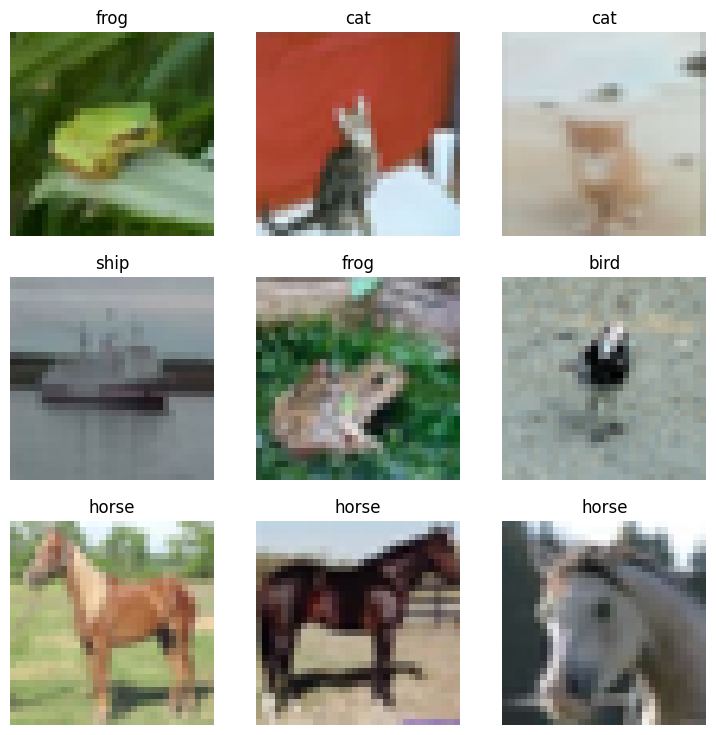

In [ ]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Create the appropriate transform, load/download CIFAR10 train and test datasets with transform
# ----------- <Your code> ---------------
# Refer https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Train and Test sets
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)


# ----------- <End Your code> ---------------

# Define trainloader and testloader
# ----------- <Your code> ---------------
batchSize = 9

train_loader = torch.utils.data.DataLoader(dataset=trainset, batch_size=batchSize, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=testset, batch_size=batchSize, shuffle=False)

# ----------- <End Your code> ---------------

# Code to display images
batch_idx, (images, targets) = next(enumerate(train_loader)) #fix!!!!!
fig, ax = plt.subplots(3,3,figsize = (9,9))
for i in range(3):
    for j in range(3):
        image = images[i*3+j].permute(1,2,0)
        image = image/2 + 0.5
        ax[i,j].imshow(image)
        ax[i,j].set_axis_off()
        ax[i,j].set_title(f'{classes[targets[i*3+j]]}')
fig.show()

### Task 2: Create CNN and train it
Set up a convolutional neural network and have your data trained on it. You have to decide all the details in your network, overall your neural network should meet the following standards to receive full credit:

*   You should not use more than three convolutional layers and three fully connected layers
*   Accuracy on the test dataset should be **above** 50%



In [ ]:
# Create CNN network.
# ----------- <Your code> ---------------
class Cifar10CNN(nn.Module):
  def __init__(self):
    super(Cifar10CNN, self).__init__()

    # CIFAR10 has 3 instead of 1 input channel like MNIST
    self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

    self.L1 = nn.Linear(64 * 4 * 4, 300)
    self.L2 = nn.Linear(300, 10)

  def forward(self, x):
    # Input = 3x32x32 Image, 16 filters, output = 16 x 32 x 32
    x = self.conv1(x)
    x = F.relu(x)
    # Max Pool Kernel 2x2 therefore output is 16x16x16
    x = F.max_pool2d(x, 2)

    # Input = 16x16x16 32 filters Output = 32x16x16
    x = self.conv2(x)
    x = F.relu(x)
    # Max Pool Kernel is 2x2, Output is = 32x8x8
    x = F.max_pool2d(x, 2)

    # Input = 32x8x8 64 filters Output = 64x4x4
    x = self.conv3(x)
    x = F.relu(x)
    # Max Pool Kernel is 2x2, Output is = 32x8x8
    x = F.max_pool2d(x, 2)

    # Flatten to use fully connected layer Input = 1024
    # Could Hard code as x.view(-1, 1024)
    x = x.view(x.size(0), -1)

    # Hidden Layer choice = 300
    x = self.L1(x)
    x = F.relu(x)

    # Hidden Layer choice = 300 to 10
    x = self.L2(x)

    return x

# ----------- <End Your code> ---------------

In [ ]:
# Train your neural network here.
start = time.time()
max_epoch = 4
# ----------- <Your code> ---------------
# Send to GPU
net = Cifar10CNN().to(device)

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimize with SGD
optimizer = optim.SGD(net.parameters(), lr=0.005, momentum=0.9)

for epoch in range(1, max_epoch + 1):
    train(net, criterion, optimizer, train_loader, epoch)
    test(net, criterion, test_loader, epoch)

# ----------- <End Your code> ---------------
output = test(net, criterion, test_loader, epoch)
end = time.time()
print(f'Finished Training after {end-start} s ')

Epoch 1: [0/50000] Loss: 2.298
Epoch 1: [6246/50000] Loss: 1.871
Epoch 1: [12492/50000] Loss: 1.401
Epoch 1: [18738/50000] Loss: 1.180
Epoch 1: [24984/50000] Loss: 1.485
Epoch 1: [31230/50000] Loss: 1.471
Epoch 1: [37476/50000] Loss: 0.947
Epoch 1: [43722/50000] Loss: 1.480
Epoch 1: [49968/50000] Loss: 1.497
Test result on epoch 1: total sample: 10000, Avg loss: 1.149, Acc: 59.000%
Epoch 2: [0/50000] Loss: 0.888
Epoch 2: [6246/50000] Loss: 0.874
Epoch 2: [12492/50000] Loss: 1.070
Epoch 2: [18738/50000] Loss: 1.317
Epoch 2: [24984/50000] Loss: 0.710
Epoch 2: [31230/50000] Loss: 1.179
Epoch 2: [37476/50000] Loss: 1.135
Epoch 2: [43722/50000] Loss: 0.933
Epoch 2: [49968/50000] Loss: 1.054
Test result on epoch 2: total sample: 10000, Avg loss: 0.960, Acc: 67.130%
Epoch 3: [0/50000] Loss: 1.193
Epoch 3: [6246/50000] Loss: 0.751
Epoch 3: [12492/50000] Loss: 0.713
Epoch 3: [18738/50000] Loss: 1.099
Epoch 3: [24984/50000] Loss: 0.316
Epoch 3: [31230/50000] Loss: 0.786
Epoch 3: [37476/50000] Lo

### Task 3: Plot misclassified test images
Plot some misclassified images in your test dataset:

*   select three images that are **misclassified** by your neural network
*   label each images with true label and predicted label
*   use `detach().cpu()` when plotting images if the image is in gpu

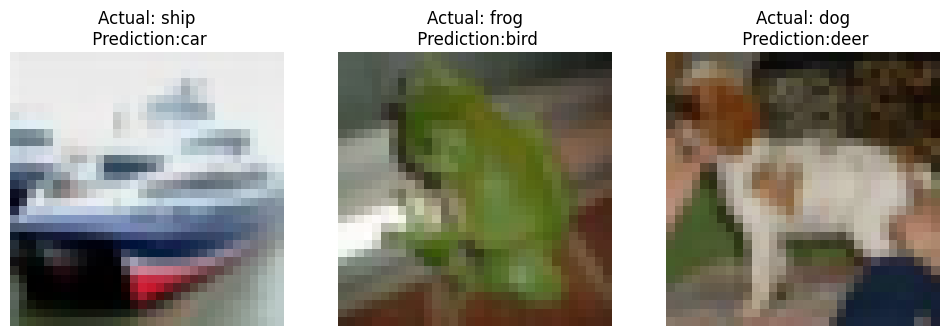

In [ ]:
total_images = 3
predictions = output['prediction']
targets = torch.tensor(testset.targets)
# ----------- <Your code> ---------------
# Mask values (True = wrong)
incorrect = (predictions != targets)

# Index for wrong values
# Refer https://docs.pytorch.org/docs/stable/generated/torch.where.html
misclassified = torch.where(incorrect)[0]

# Select images
sampleIdx = misclassified[:total_images]

# Plot
fig, ax = plt.subplots(1, total_images, figsize = (12,4))

for i in range(total_images):
  image , trueLabel = testset[sampleIdx[i]]
  # Move to CPU and detach
  image = image.detach().cpu()
  predLabel = predictions[sampleIdx[i]].item()
  image = image/2 + 0.5
  image = image.permute(1,2,0)

  ax[i].imshow(image)
  ax[i].set_axis_off()
  ax[i].set_title("Actual: " + classes[trueLabel] + "\n Prediction:" + classes[predLabel])

# ----------- <End Your code> ---------------

Questions (0 points): Are the mis-classified images also misleading to human eyes?

I can see how they could be misleading. Especially when colors are similar to other photos or the crop is very close.

## Exercise 4: Transfer Learning (30 points)

In practice, people won't train an entire CNN from scratch, because it is relatively rare to have a dataset of sufficient size (or sufficient computational power). Instead, it is common to pretrain a CNN on a very large dataset and then use the CNN either as an initialization or a fixed feature extractor for the task of interest.

In this task, you will learn how to use a pretrained CNN for CIFAR-10 classification.

### Task1: Load pretrained model

`torchvision.models` (https://pytorch.org/vision/stable/models.html) contains definitions of models for addressing different tasks, including: image classification, pixelwise semantic segmentation, object detection, instance segmentation, person keypoint detection and video classification.

First, you should load the **pretrained** ResNet-18 that has already been trained on [ImageNet](https://www.image-net.org/) using `torchvision.models`. If you are interested in more details about Resnet-18, read this paper https://arxiv.org/pdf/1512.03385.pdf. Remember to also move this model to the GPU.

In [ ]:
# ----------- <Your code> ---------------
# Reference torchvision.models
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet18 = resnet18.to(device)
# ----------- <End Your code> ---------------

### Task2: Create data loaders for CIFAR-10

Then you need to create a modified dataset and dataloader for CIFAR-10. Importantly, the model you load has been trained on **ImageNet** and it expects inputs as mini-batches of 3-channel RGB images of shape (3 x H x W), where H and W are expected to be **at least** 224. So you need to preprocess the CIFAR-10 data to make sure it has a height and width of 224. Thus, you should add a transform when loading the CIFAR10 dataset (see [`torchvision.transforms.Resize`](https://pytorch.org/vision/stable/transforms.html#torchvision.transforms.Resize)).
This should be added appropriately to the `transform` you created in a previous task.

In [ ]:
# Create your dataloader here
# ----------- <Your code> ---------------
transform = transforms.Compose(
    [transforms.Resize(224),
     transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Train and Test Set Load (Reset)
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

# Adjust for noise
batchSize = 64

train_loader = torch.utils.data.DataLoader(dataset=trainset, batch_size=batchSize, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=testset, batch_size=batchSize, shuffle=False)

# ----------- <End Your code> ---------------

### Task3: Classify test data on pretrained model

Use the model you load to classify the **test** CIFAR-10 data and print out the test accuracy.

Don't be surprised if the accuracy is bad!

In [ ]:
# ----------- <Your code> ---------------
# Loss Function
criterion = nn.CrossEntropyLoss()

result = test(resnet18, criterion, test_loader,0)
# ----------- <End Your code> ---------------

Test result on epoch 0: total sample: 10000, Avg loss: 11.709, Acc: 0.030%


### Task 4: Fine-tune (i.e., update) the pretrained model for CIFAR-10

Now try to improve the test accuracy. We offer several possible solutions:

(1) You can try to directly continue to train the model you load with the CIFAR-10 training data.

(2) For efficiency, you can try to freeze part of the parameters of the loaded models. For example, you can first freeze all parameters by

```
for param in model.parameters():
    param.requires_grad = False
```
and then unfreeze the last few layers by setting `somelayer.requires_grad=True`.

You are also welcome to try any other approach you can think of.


**Note:** You must print out the test accuracy and to get full credits, the test accuracy should be at least **80%**.

In [ ]:
# Directly train the whole model.
start = time.time()
#----------- <Your code> ---------------
# Reload Resnet18 in case of changes
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Have to edit last layer to 10 output channels for CIFAR10 match
num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, 10)

# Send to GPU
resnet18 = resnet18.to(device)

criterion = nn.CrossEntropyLoss()
max_epoch = 1

optimizer = optim.SGD(resnet18.parameters(), lr=0.001, momentum=0.9)

for epoch in range(1, max_epoch + 1):
    train(resnet18, criterion, optimizer, train_loader, epoch)
    test(resnet18, criterion, test_loader, epoch)
# ----------- <End Your code> ---------------
test(resnet18, criterion, test_loader, epoch)
end = time.time()
print(f'Finished Training after {end-start} s ')

Epoch 1: [0/50000] Loss: 2.299
Epoch 1: [6208/50000] Loss: 0.538
Epoch 1: [12416/50000] Loss: 0.550
Epoch 1: [18624/50000] Loss: 0.384
Epoch 1: [24832/50000] Loss: 0.341
Epoch 1: [31040/50000] Loss: 0.191
Epoch 1: [37248/50000] Loss: 0.205
Epoch 1: [43456/50000] Loss: 0.229
Epoch 1: [49664/50000] Loss: 0.371
Test result on epoch 1: total sample: 10000, Avg loss: 0.225, Acc: 92.230%
Test result on epoch 1: total sample: 10000, Avg loss: 0.225, Acc: 92.230%
Finished Training after 63.05414366722107 s 


In [ ]:
# Load another resnet18 instance, only unfreeze the outer layers.
# ----------- <Your code> ---------------
# Reload in case of feature change
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze Layers
for param in resnet18.parameters():
    param.requires_grad = False

# Unfreeze Layer 4 of Resnet
for param in resnet18.layer4.parameters():
    param.requires_grad = True

# Refer https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html
features = resnet18.fc.in_features
resnet18.fc = nn.Linear(features, 10)

# Send Resnet to GPU to train
resnet18 = resnet18.to(device)

# ----------- <End Your code> ---------------

In [ ]:
# Train the model!!
start = time.time()
# ----------- <Your code> ---------------
criterion = nn.CrossEntropyLoss()
max_epoch = 1

optimizer = optim.SGD(resnet18.parameters(), lr=0.004, momentum=0.9)

for epoch in range(1, max_epoch + 1):
    train(resnet18, criterion, optimizer, train_loader, epoch)
    test(resnet18, criterion, test_loader, epoch)

# ----------- <End Your code> ---------------
test(resnet18, criterion, test_loader)
end = time.time()
print(f'Finished Training after {end-start} s ')

Epoch 1: [0/50000] Loss: 2.468
Epoch 1: [6208/50000] Loss: 0.409
Epoch 1: [12416/50000] Loss: 0.591
Epoch 1: [18624/50000] Loss: 0.537
Epoch 1: [24832/50000] Loss: 0.506
Epoch 1: [31040/50000] Loss: 0.497
Epoch 1: [37248/50000] Loss: 0.232
Epoch 1: [43456/50000] Loss: 0.509
Epoch 1: [49664/50000] Loss: 0.287
Test result on epoch 1: total sample: 10000, Avg loss: 0.322, Acc: 89.130%
Test result on epoch 0: total sample: 10000, Avg loss: 0.322, Acc: 89.130%
Finished Training after 55.36720633506775 s 
